In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from StockPickingModel import StockPickingModel

In [2]:
import pandas as pd
import requests

target_date = pd.Timestamp("2026-03-01")

url = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"
headers = {"User-Agent": "Mozilla/5.0"}

resp = requests.get(url, headers=headers, timeout=30)
resp.raise_for_status()

tables = pd.read_html(resp.text)

# Tabla 0: composición actual
df_const = tables[0].copy()
tickers = set(df_const["Symbol"].astype(str).str.strip())

# Tabla 1: cambios históricos (normalmente es la segunda tabla)
df_chg = tables[1].copy()

# Aplanar columnas si vienen como MultiIndex
if isinstance(df_chg.columns, pd.MultiIndex):
    df_chg.columns = [" ".join([str(x) for x in c if str(x) != "nan"]).strip().lower() for c in df_chg.columns]
else:
    df_chg.columns = [str(c).strip().lower() for c in df_chg.columns]

# Detectar columnas
date_col = next(c for c in df_chg.columns if "date" in c)
add_col = next(c for c in df_chg.columns if ("added" in c and "ticker" in c) or c == "added")
rem_col = next(c for c in df_chg.columns if ("removed" in c and "ticker" in c) or c == "removed")

df_chg[date_col] = pd.to_datetime(df_chg[date_col], errors="coerce")

# Deshacer cambios posteriores a target_date
after = df_chg[df_chg[date_col] > target_date].sort_values(date_col, ascending=False)

for _, row in after.iterrows():
    added = str(row.get(add_col, "")).strip()
    removed = str(row.get(rem_col, "")).strip()

    if added and added.lower() != "nan":
        tickers.discard(added)
    if removed and removed.lower() != "nan":
        tickers.add(removed)

tickers_2020 = sorted(tickers)

print(f"Tickers S&P 500 a {target_date.date()}: {len(tickers_2020)}")
print(tickers_2020[:20])
len(tickers_2020)

C:\Users\jpuerta\AppData\Local\Temp\ipykernel_7492\374810351.py:12: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables = pd.read_html(resp.text)


Tickers S&P 500 a 2026-03-01: 503
['A', 'AAPL', 'ABBV', 'ABNB', 'ABT', 'ACGL', 'ACN', 'ADBE', 'ADI', 'ADM', 'ADP', 'ADSK', 'AEE', 'AEP', 'AES', 'AFL', 'AIG', 'AIZ', 'AJG', 'AKAM']


503

c:\Users\jpuerta\OneDrive - Analistas Financieros Internacionales (Afi)\Documentos\Master Quant\Gestión de activos\Trabajo gestión cuantitativa\Trabajo_gestion_cuantitativa\StockPickingModel.py:33: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables = pd.read_html(requests.get(url, headers={"User-Agent": "Mozilla/5.0"}, timeout=30).text)
[*                      2%                       ]  11 of 592 completed$XLNX: possibly delisted; no timezone found
[*                      3%                       ]  16 of 592 completed$CTLT: possibly delisted; no timezone found
[*****                 10%                       ]  57 of 592 completed$TIF: possibly delisted; no timezone found
[******                12%                       ]  73 of 592 completed$FLIR: possibly delisted; no timezone found
[********              16%                       ]  95 of 592 completed$MXI

=== Métricas ===


c:\Users\jpuerta\OneDrive - Analistas Financieros Internacionales (Afi)\Documentos\Master Quant\Gestión de activos\Trabajo gestión cuantitativa\Trabajo_gestion_cuantitativa\StockPickingModel.py:262: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '115.34%' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  tabla_fmt.loc[c] = tabla_fmt.loc[c].map(lambda x: f"{x:.2%}")
c:\Users\jpuerta\OneDrive - Analistas Financieros Internacionales (Afi)\Documentos\Master Quant\Gestión de activos\Trabajo gestión cuantitativa\Trabajo_gestion_cuantitativa\StockPickingModel.py:262: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '52.72%' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  tabla_fmt.loc[c] = tabla_fmt.loc[c].map(lambda x: f"{x:.2%}")


,ML,B&H EW
Total,115.34%,52.72%
CAGR,27.53%,14.37%
Vol,23.55%,13.23%
Sharpe,1.07,0.93
MaxDD,-21.70%,-12.92%
Hit,57.32%,59.76%


=== Rentabilidad Anual ===


c:\Users\jpuerta\OneDrive - Analistas Financieros Internacionales (Afi)\Documentos\Master Quant\Gestión de activos\Trabajo gestión cuantitativa\Trabajo_gestion_cuantitativa\StockPickingModel.py:269: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  anual = pd.concat([(1+ret_ml).resample("Y").prod()-1, (1+ret_bh).resample("Y").prod()-1], axis=1)


,ML,B&H EW
Fecha,,
2023,19.03%,12.38%
2024,16.70%,15.01%
2025,31.89%,13.79%
2026,17.55%,3.83%


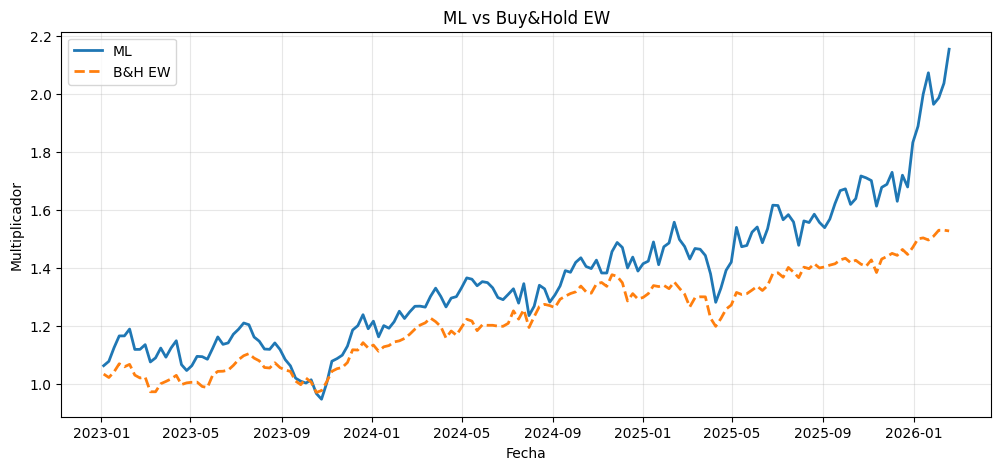

In [4]:
# tickers = [
#     "AAPL", "MSFT", "AMZN", "GS", "UNH", "V", "HD", "CRM", "CAT", "MA",
#     "JNJ", "PG", "WMT", "JPM", "AXP", "CVX", "DIS", "BA", "MCD", "MMM",
#     "INTC", "TRV", "IBM", "MRK", "NKE", "VZ", "HON", "CSCO", "AMGN", "KO"
# ]
spm = StockPickingModel(
    start_date="2021-01-01",
    end_date="2026-03-03",
    criterio=20,          # o "mediana"
    len_ventana=2,
    n_activos_obj=20,
    umbral_salida=28
)
resultados, rendimiento_total = spm.run_backtest(coste_operacion=0.001)

=== Métricas ===


c:\Users\jpuerta\OneDrive - Analistas Financieros Internacionales (Afi)\Documentos\Master Quant\Gestión de activos\Trabajo gestión cuantitativa\Trabajo_gestion_cuantitativa\StockPickingModel.py:214: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '936.04%' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  tabla_fmt.loc[c] = tabla_fmt.loc[c].map(lambda x: f"{x:.2%}")
c:\Users\jpuerta\OneDrive - Analistas Financieros Internacionales (Afi)\Documentos\Master Quant\Gestión de activos\Trabajo gestión cuantitativa\Trabajo_gestion_cuantitativa\StockPickingModel.py:214: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '103.66%' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  tabla_fmt.loc[c] = tabla_fmt.loc[c].map(lambda x: f"{x:.2%}")


,ML,B&H EW
Total,936.04%,103.66%
CAGR,109.87%,25.30%
Vol,41.41%,16.02%
Sharpe,1.95,1.37
MaxDD,-27.68%,-16.58%
Hit,60.98%,62.20%


=== Rentabilidad Anual ===


c:\Users\jpuerta\OneDrive - Analistas Financieros Internacionales (Afi)\Documentos\Master Quant\Gestión de activos\Trabajo gestión cuantitativa\Trabajo_gestion_cuantitativa\StockPickingModel.py:221: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  anual = pd.concat([(1+ret_ml).resample("Y").prod()-1, (1+ret_bh).resample("Y").prod()-1], axis=1)


,ML,B&H EW
Fecha,,
2023,82.24%,20.77%
2024,58.88%,33.53%
2025,169.27%,27.96%
2026,32.88%,-1.31%


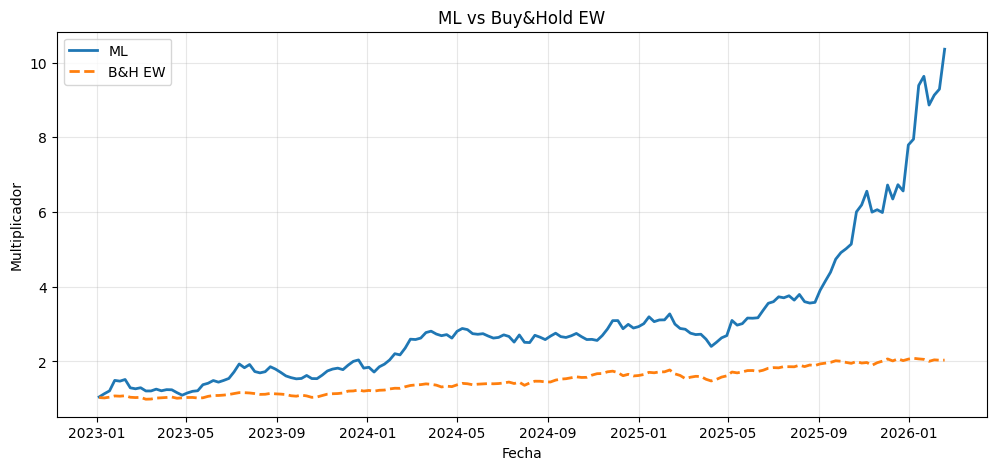

Filas backtest: 164
Rendimiento total: 936.04%
       Fecha  Retorno_Neto     Curva
0 2023-01-04      0.051019  1.051019
1 2023-01-11      0.081810  1.137003
2 2023-01-18      0.067990  1.214308
3 2023-01-25      0.229908  1.493487
4 2023-02-01     -0.013198  1.473776


In [10]:
resultados, rendimiento_total = spm.run_backtest(coste_operacion=0.001)

print(f"Filas backtest: {len(resultados)}")
print(f"Rendimiento total: {rendimiento_total:.2f}%")
print(resultados.head())

# if len(resultados) > 0:
#     plt.figure(figsize=(10,5))
#     plt.plot(resultados["Fecha"], resultados["Curva"], lw=2)
#     plt.title("Curva de capital - Backtest")
#     plt.xlabel("Fecha")
#     plt.ylabel("Multiplicador")
#     plt.grid(alpha=0.3)
#     plt.show()

In [11]:
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt

# # =========================
# # 1) Retornos estrategia ML
# # =========================
# ret_ml = resultados.set_index("Fecha")["Retorno_Neto"].copy()

# # =========================================
# # 2) Benchmark: estática equiponderada (EW)
# #    (pesos iguales al inicio, luego drift)
# # =========================================
# r_next = spm.df.pivot_table(index="Fecha", columns="Ticker", values="Retorno_Next_Week")

# # mismas fechas que la estrategia para comparar manzana con manzana
# r_next = r_next.loc[ret_ml.index]

# # pesos iniciales iguales en activos disponibles al inicio
# primera_fecha = r_next.index[0]
# activos_ini = r_next.loc[primera_fecha].dropna().index.tolist()
# w = pd.Series(0.0, index=r_next.columns)
# w.loc[activos_ini] = 1.0 / len(activos_ini)

# ret_bh = []
# for fecha in r_next.index:
#     r = r_next.loc[fecha].fillna(0.0)     # si falta dato, asumimos 0 esa semana
#     rp = float((w * r).sum())             # retorno cartera semana t
#     ret_bh.append(rp)

#     # actualizar pesos (buy & hold, sin rebalanceo)
#     w = w * (1.0 + r)
#     if w.sum() > 0:
#         w = w / w.sum()

# ret_bh = pd.Series(ret_bh, index=r_next.index, name="Retorno_BH")

# # =====================
# # 3) Métricas estándar
# # =====================
# def metrics(r, freq=52, rf_anual=0.02):
#     r = r.dropna()
#     if len(r) == 0:
#         return pd.Series(dtype=float)

#     rf_w = (1 + rf_anual) ** (1 / freq) - 1
#     curva = (1 + r).cumprod()

#     total_return = curva.iloc[-1] - 1
#     cagr = curva.iloc[-1] ** (freq / len(r)) - 1
#     vol_anual = r.std(ddof=1) * np.sqrt(freq)

#     exceso = r - rf_w
#     sharpe = np.nan if vol_anual == 0 else (exceso.mean() * freq) / vol_anual

#     downside = np.minimum(exceso, 0)
#     downside_vol = np.sqrt((downside**2).mean()) * np.sqrt(freq)
#     sortino = np.nan if downside_vol == 0 else (exceso.mean() * freq) / downside_vol

#     dd = curva / curva.cummax() - 1
#     max_dd = dd.min()
#     calmar = np.nan if max_dd == 0 else cagr / abs(max_dd)

#     return pd.Series({
#         "Total Return": total_return,
#         "CAGR": cagr,
#         "Vol Anual": vol_anual,
#         "Sharpe": sharpe,
#         "Sortino": sortino,
#         "Max Drawdown": max_dd,
#         "Calmar": calmar
#     })

# m_ml = metrics(ret_ml, freq=52, rf_anual=0.02)
# m_bh = metrics(ret_bh, freq=52, rf_anual=0.02)

# tabla = pd.concat([m_ml, m_bh], axis=1)
# tabla.columns = ["ML + Buffer", "EW Estática"]

# # Formato %
# tabla_fmt = tabla.copy()
# for c in ["Total Return", "CAGR", "Vol Anual", "Max Drawdown"]:
#     tabla_fmt.loc[c] = tabla_fmt.loc[c].map(lambda x: f"{x:.2%}")
# for c in ["Sharpe", "Sortino", "Calmar"]:
#     tabla_fmt.loc[c] = tabla_fmt.loc[c].map(lambda x: f"{x:.2f}")

# print("=== Comparativa de métricas ===")
# display(tabla_fmt)

# # =====================
# # 4) Curvas comparadas
# # =====================
# curva_ml = (1 + ret_ml).cumprod()
# curva_bh = (1 + ret_bh).cumprod()

# plt.figure(figsize=(12,6))
# plt.plot(curva_ml.index, curva_ml.values, label="ML + Buffer", lw=2.2)
# plt.plot(curva_bh.index, curva_bh.values, label="EW Estática (Buy&Hold)", lw=2, linestyle="--")
# plt.title("ML vs Benchmark Estático Equiponderado")
# plt.xlabel("Fecha")
# plt.ylabel("Multiplicador")
# plt.grid(alpha=0.3)
# plt.legend()
# plt.show()  

In [12]:
# import pandas as pd
# import matplotlib.pyplot as plt

# # Asegurar índices datetime
# ret_ml_y = ret_ml.copy()
# ret_bh_y = ret_bh.copy()
# ret_ml_y.index = pd.to_datetime(ret_ml_y.index)
# ret_bh_y.index = pd.to_datetime(ret_bh_y.index)

# # Rentabilidad anual compuesta: (1+r1)*(1+r2)*...-1
# anual_ml = (1 + ret_ml_y).resample("Y").prod() - 1
# anual_bh = (1 + ret_bh_y).resample("Y").prod() - 1

# # Tabla comparativa
# tabla_anual = pd.concat([anual_ml, anual_bh], axis=1)
# tabla_anual.columns = ["ML + Buffer", "EW Estática"]
# tabla_anual.index = tabla_anual.index.year

# print("=== Rentabilidades anuales ===")
# display(tabla_anual.style.format("{:.2%}"))

# # (Opcional) gráfico barras
# ax = (tabla_anual * 100).plot(kind="bar", figsize=(11,5))
# ax.set_title("Rentabilidad anual (%)")
# ax.set_xlabel("Año")
# ax.set_ylabel("%")
# ax.grid(axis="y", alpha=0.3)
# plt.tight_layout()
# plt.show()